### Import libraries

In [181]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from datetime import datetime, timedelta

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### Import dataset 

In [182]:
DATA_PATH = '~/Projects/Aiproject/ERA5_t2m_hourly_Bologna_1952-2022_rd.nc'
ds = xr.open_dataset(DATA_PATH)
# Dataset structure
print(ds)

<xarray.Dataset> Size: 10MB
Dimensions:    (time: 622392, latitude: 1, longitude: 1)
Coordinates:
  * time       (time) datetime64[ns] 5MB 1952-01-01 ... 2022-12-31T23:00:00
  * latitude   (latitude) float32 4B 44.5
  * longitude  (longitude) float32 4B 11.25
Data variables:
    t2m        (time, latitude, longitude) float64 5MB ...
Attributes:
    CDI:          Climate Data Interface version 2.1.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Sat Mar 18 19:51:03 2023: cdo sellonlatbox,11.2,11.4,44.4,4...
    NCO:          netCDF Operators version 5.1.1 (Homepage = http://nco.sf.ne...
    CDO:          Climate Data Operators version 2.1.0 (https://mpimet.mpg.de...


### Extract temperature and convert to Celsius

In [183]:
t2m_kelvin = ds['t2m'].squeeze()  # Remove singleton lat/lon dimensions
t2m_celsius = t2m_kelvin - 273.15

### Convert to pandas Series for easier manipulation

In [184]:
temp_hourly = t2m_celsius.to_series()
temp_hourly.name = 'temperature'

#### Temperature statistics

In [185]:
print(temp_hourly.describe())

print(temp_hourly.isna().sum()) # Missing values

count    622392.000000
mean         14.116878
std           8.553961
min         -18.260473
25%           7.530107
50%          13.880143
75%          20.475361
max          38.283069
Name: temperature, dtype: float64
0


### Create daily aggregates 


In [186]:
temp_daily = temp_hourly.resample('D').agg(['mean', 'min', 'max'])
temp_daily.columns = ['temp_mean', 'temp_min', 'temp_max']
temp_daily['temp_range'] = temp_daily['temp_max'] - temp_daily['temp_min']

print(temp_daily)

            temp_mean  temp_min   temp_max  temp_range
time                                                  
1952-01-01   3.313276 -0.777272   6.992353    7.769625
1952-01-02   4.782486  1.654985   8.733358    7.078373
1952-01-03   6.055317  2.699589   8.737479    6.037891
1952-01-04   4.165021  1.233641   7.249898    6.016257
1952-01-05   2.769212 -0.794785   8.081254    8.876039
...               ...       ...        ...         ...
2022-12-27   9.579266  8.293471  10.707185    2.413714
2022-12-28   7.987507  6.750260  10.005632    3.255372
2022-12-29   8.398936  6.057979  11.482911    5.424933
2022-12-30   8.301756  6.543194  10.568111    4.024917
2022-12-31   9.425168  8.530413  11.094533    2.564120

[25933 rows x 4 columns]


### Time Series Overview

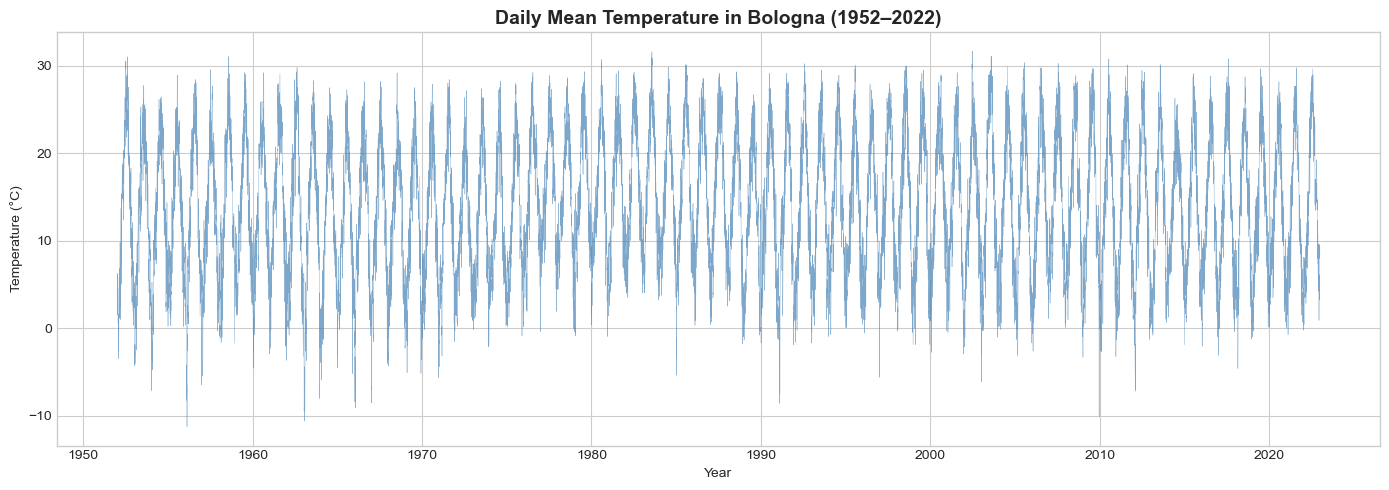

In [187]:
#  Full time series plot
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(temp_daily.index, temp_daily['temp_mean'], linewidth=0.3, alpha=0.7, color='steelblue')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Daily Mean Temperature in Bologna (1952–2022)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###  Diurnal Cycle 

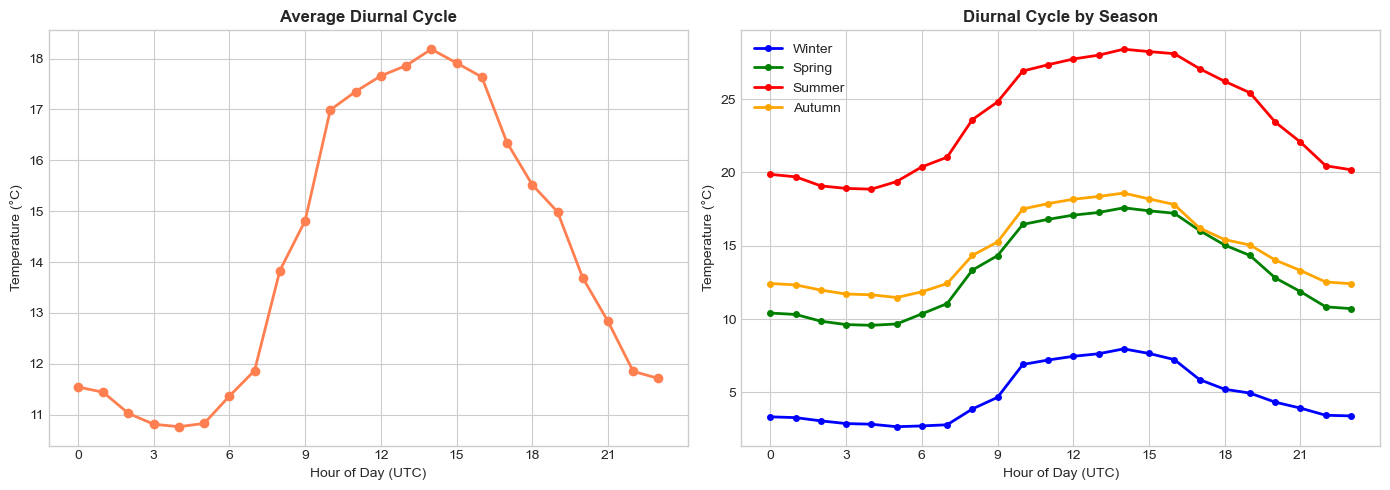

Diurnal temperature range: 7.42°C
Warmest hour: 14 (18.18°C)
Coolest hour: 4 (10.76°C)


In [188]:
hourly_df = temp_hourly.to_frame()
hourly_df['hour'] = hourly_df.index.hour
hourly_df['month'] = hourly_df.index.month

# Average by hour
diurnal_cycle = hourly_df.groupby('hour')['temperature'].mean()

# Diurnal cycle by season
seasons = {12: 'Winter', 1: 'Winter', 2: 'Winter',
           3: 'Spring', 4: 'Spring', 5: 'Spring',
           6: 'Summer', 7: 'Summer', 8: 'Summer',
           9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
hourly_df['season'] = hourly_df['month'].map(seasons)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall diurnal cycle
axes[0].plot(diurnal_cycle.index, diurnal_cycle.values, 'o-', color='coral', linewidth=2, markersize=6)
axes[0].set_xlabel('Hour of Day (UTC)')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Average Diurnal Cycle', fontweight='bold')
axes[0].set_xticks(range(0, 24, 3))

# Diurnal cycle by season
colors = {'Winter': 'blue', 'Spring': 'green', 'Summer': 'red', 'Autumn': 'orange'}
for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
    seasonal_diurnal = hourly_df[hourly_df['season'] == season].groupby('hour')['temperature'].mean()
    axes[1].plot(seasonal_diurnal.index, seasonal_diurnal.values, 'o-', 
                 label=season, color=colors[season], linewidth=2, markersize=4)

axes[1].set_xlabel('Hour of Day (UTC)')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title('Diurnal Cycle by Season', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()
print(f'Diurnal temperature range: {diurnal_cycle.max() - diurnal_cycle.min():.2f}°C')
print(f'Warmest hour: {diurnal_cycle.idxmax()} ({diurnal_cycle.max():.2f}°C)')
print(f'Coolest hour: {diurnal_cycle.idxmin()} ({diurnal_cycle.min():.2f}°C)')

### Seasonal Cycle and Monthly Climatology

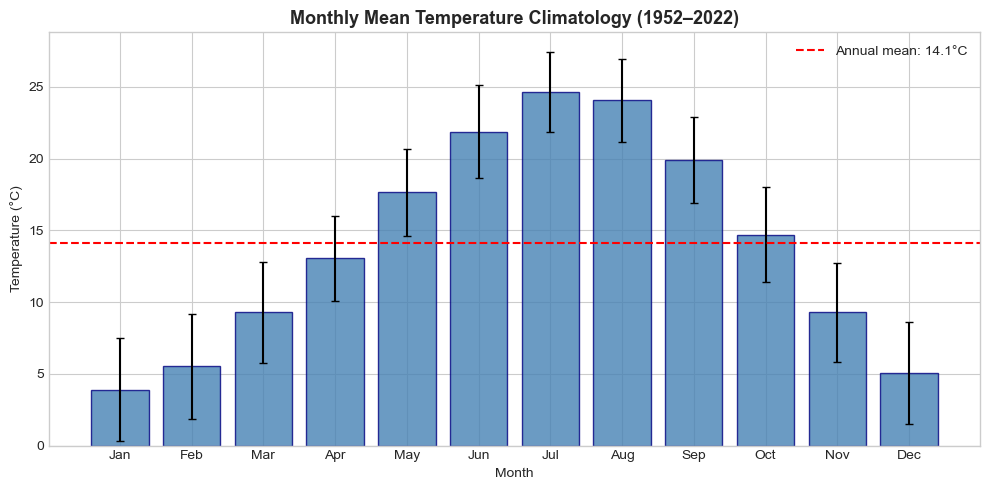

In [189]:
# Monthly climatology
temp_daily['month'] = temp_daily.index.month
monthly_clim = temp_daily.groupby('month')['temp_mean'].agg(['mean', 'std'])

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(monthly_clim.index, monthly_clim['mean'], yerr=monthly_clim['std'],
       color='steelblue', alpha=0.8, capsize=3, edgecolor='navy')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Monthly Mean Temperature Climatology (1952–2022)', fontsize=13, fontweight='bold')
ax.axhline(y=temp_daily['temp_mean'].mean(), color='red', linestyle='--', label=f'Annual mean: {temp_daily["temp_mean"].mean():.1f}°C')
ax.legend()
plt.tight_layout()
plt.show()

### Annual Trend and Climate Change Signal

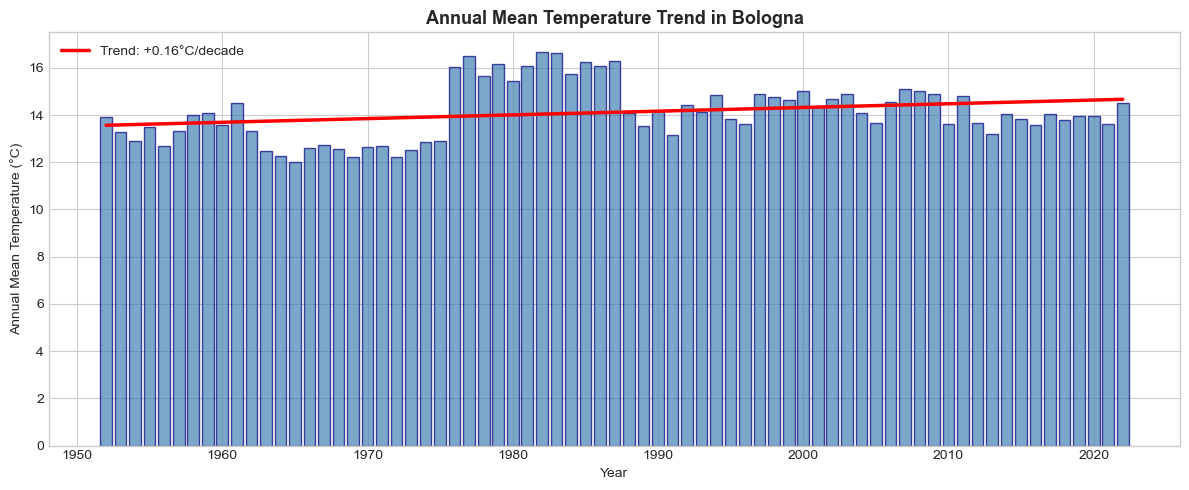

Warming rate: 0.157°C per decade
Total warming (1952–2022): 1.10°C
Coldest year: 1965 (12.03°C)
Warmest year: 1982 (16.67°C)


In [190]:
# Annual mean temperature
temp_daily['year'] = temp_daily.index.year
annual_mean = temp_daily.groupby('year')['temp_mean'].mean()

# Linear trend
years = annual_mean.index.values
temps = annual_mean.values
slope, intercept = np.polyfit(years, temps, 1)
trend_line = slope * years + intercept

# Warming rate
warming_per_decade = slope * 10
total_warming = slope * (years[-1] - years[0])

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(years, temps, color='steelblue', alpha=0.7, edgecolor='navy', width=0.8)
ax.plot(years, trend_line, 'r-', linewidth=2.5, label=f'Trend: +{warming_per_decade:.2f}°C/decade')
ax.set_xlabel('Year')
ax.set_ylabel('Annual Mean Temperature (°C)')
ax.set_title('Annual Mean Temperature Trend in Bologna', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f'Warming rate: {warming_per_decade:.3f}°C per decade')
print(f'Total warming (1952–2022): {total_warming:.2f}°C')
print(f'Coldest year: {years[np.argmin(temps)]} ({temps.min():.2f}°C)')
print(f'Warmest year: {years[np.argmax(temps)]} ({temps.max():.2f}°C)')

### Temperature Anomalies (1991–2020 Baseline)

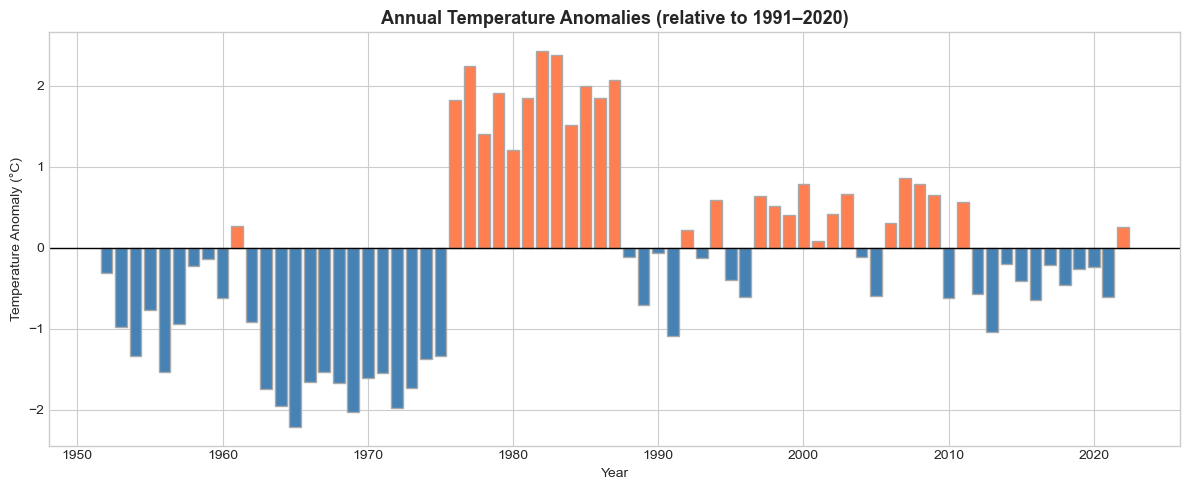

Baseline period mean (1991-2020): 14.23°C
Most negative anomaly: 1965 (-2.21°C)
Most positive anomaly: 1982 (2.43°C)


In [191]:
# Calculate anomalies relative to 1991-2020 baseline (WMO standard)
baseline_mask = (temp_daily.index >= '1991-01-01') & (temp_daily.index <= '2020-12-31')
baseline_mean = temp_daily.loc[baseline_mask, 'temp_mean'].mean()

# Monthly baseline for seasonal anomalies
monthly_baseline = temp_daily.loc[baseline_mask].groupby('month')['temp_mean'].mean()
temp_daily['monthly_baseline'] = temp_daily['month'].map(monthly_baseline)
temp_daily['anomaly'] = temp_daily['temp_mean'] - temp_daily['monthly_baseline']

# Annual anomalies
annual_anomaly = temp_daily.groupby('year')['anomaly'].mean()

# Color by anomaly sign
colors = ['steelblue' if x < 0 else 'coral' for x in annual_anomaly.values]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(annual_anomaly.index, annual_anomaly.values, color=colors, edgecolor='darkgray', width=0.8)
ax.axhline(y=0, color='black', linewidth=1)
ax.set_xlabel('Year')
ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_title('Annual Temperature Anomalies (relative to 1991–2020)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Baseline period mean (1991-2020): {baseline_mean:.2f}°C')
print(f'Most negative anomaly: {annual_anomaly.idxmin()} ({annual_anomaly.min():.2f}°C)')
print(f'Most positive anomaly: {annual_anomaly.idxmax()} ({annual_anomaly.max():.2f}°C)')

### Extreme Events Analysis

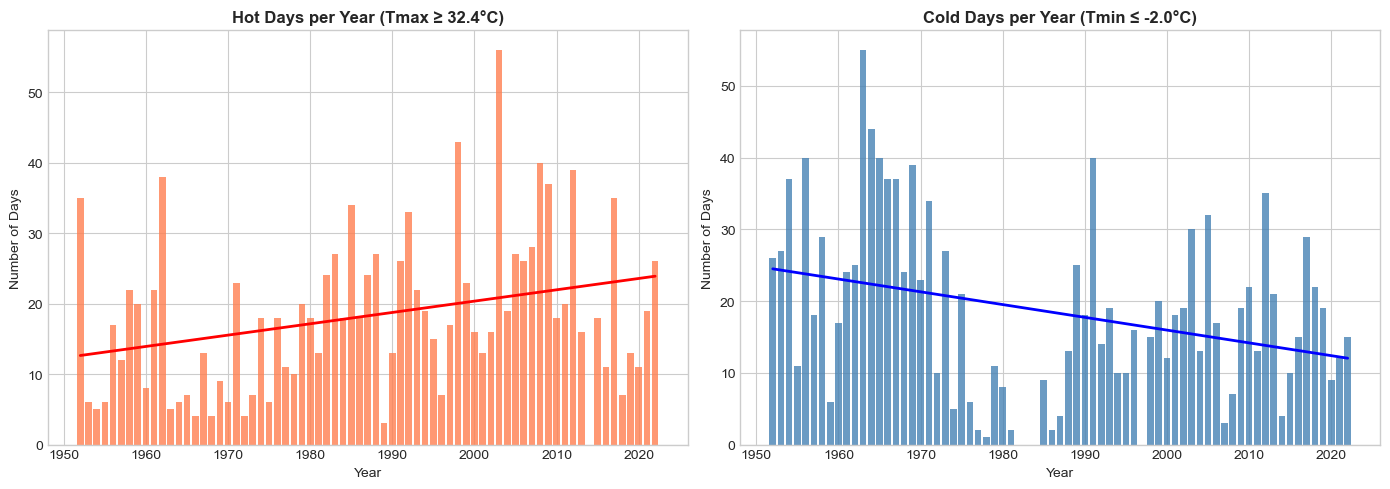

Hot day threshold (95th percentile): 32.4°C
Cold day threshold (5th percentile): -2.0°C

Trend in hot days: 1.6 days/decade
Trend in cold days: -1.8 days/decade


In [192]:
# Define extreme thresholds
hot_threshold = temp_daily['temp_max'].quantile(0.95)  # 95th percentile
cold_threshold = temp_daily['temp_min'].quantile(0.05)  # 5th percentile

# Count extreme days per year
temp_daily['hot_day'] = temp_daily['temp_max'] >= hot_threshold
temp_daily['cold_day'] = temp_daily['temp_min'] <= cold_threshold

hot_days_per_year = temp_daily.groupby('year')['hot_day'].sum()
cold_days_per_year = temp_daily.groupby('year')['cold_day'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hot days trend
axes[0].bar(hot_days_per_year.index, hot_days_per_year.values, color='coral', alpha=0.8)
z = np.polyfit(hot_days_per_year.index, hot_days_per_year.values, 1)
axes[0].plot(hot_days_per_year.index, np.poly1d(z)(hot_days_per_year.index), 'r-', linewidth=2)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Days')
axes[0].set_title(f'Hot Days per Year (Tmax ≥ {hot_threshold:.1f}°C)', fontweight='bold')

# Cold days trend
axes[1].bar(cold_days_per_year.index, cold_days_per_year.values, color='steelblue', alpha=0.8)
z = np.polyfit(cold_days_per_year.index, cold_days_per_year.values, 1)
axes[1].plot(cold_days_per_year.index, np.poly1d(z)(cold_days_per_year.index), 'b-', linewidth=2)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Days')
axes[1].set_title(f'Cold Days per Year (Tmin ≤ {cold_threshold:.1f}°C)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Hot day threshold (95th percentile): {hot_threshold:.1f}°C')
print(f'Cold day threshold (5th percentile): {cold_threshold:.1f}°C')
print(f'\nTrend in hot days: {np.polyfit(hot_days_per_year.index, hot_days_per_year.values, 1)[0] * 10:.1f} days/decade')
print(f'Trend in cold days: {np.polyfit(cold_days_per_year.index, cold_days_per_year.values, 1)[0] * 10:.1f} days/decade')

### Decadal Distributions

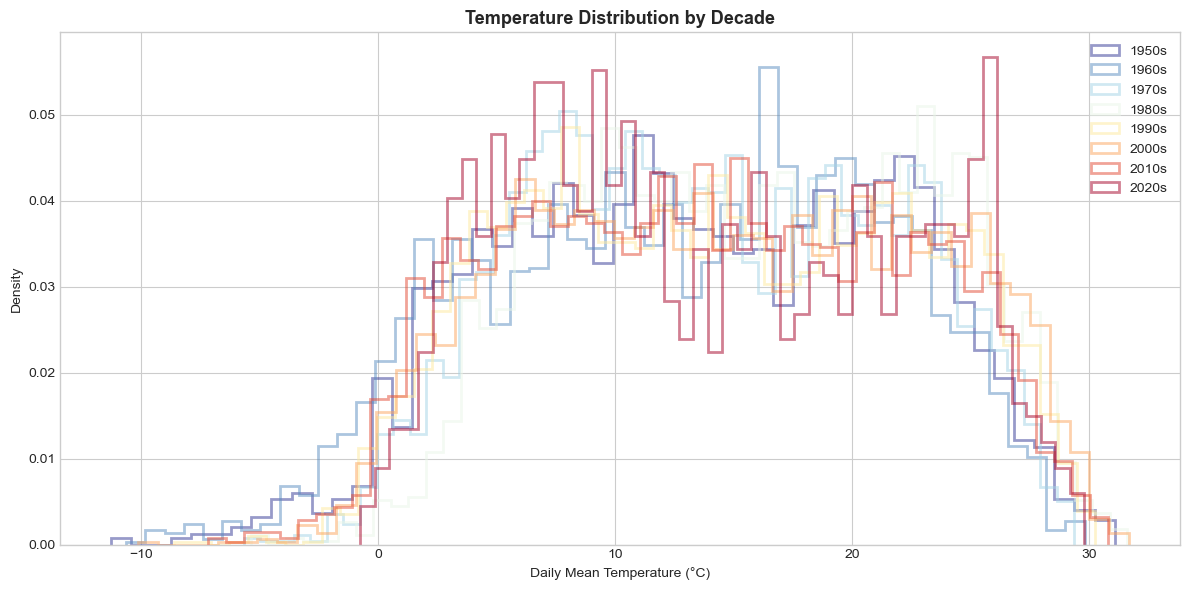

Decadal mean temperatures:
1950s: 13.46°C
1960s: 12.83°C
1970s: 14.02°C
1980s: 15.68°C
1990s: 14.25°C
2000s: 14.62°C
2010s: 13.85°C
2020s: 14.03°C


In [193]:
# Temperature distribution by decade
temp_daily['decade'] = (temp_daily['year'] // 10) * 10
decades = sorted(temp_daily['decade'].unique())

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlBu_r(np.linspace(0, 1, len(decades)))

for i, decade in enumerate(decades):
    decade_data = temp_daily[temp_daily['decade'] == decade]['temp_mean']
    ax.hist(decade_data, bins=50, alpha=0.5, label=f'{decade}s', 
            color=colors[i], density=True, histtype='step', linewidth=2)

ax.set_xlabel('Daily Mean Temperature (°C)')
ax.set_ylabel('Density')
ax.set_title('Temperature Distribution by Decade', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Decadal statistics
print('Decadal mean temperatures:')
for decade in decades:
    decade_mean = temp_daily[temp_daily['decade'] == decade]['temp_mean'].mean()
    print(f'{decade}s: {decade_mean:.2f}°C')

##  Feature Engineering

In [194]:
# Create features for ML models (using daily data)
df = temp_daily[['temp_mean']].copy()

# Temporal features
df['day_of_year'] = df.index.dayofyear
df['month'] = df.index.month
df['year'] = df.index.year

# Cyclical encoding for seasonal patterns
df['sin_day'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['cos_day'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)

# Lag features (past temperatures)
for lag in [1, 2, 3, 7, 14, 30, 365]:
    df[f'lag_{lag}'] = df['temp_mean'].shift(lag)

# Rolling statistics
df['rolling_mean_7'] = df['temp_mean'].shift(1).rolling(window=7).mean()
df['rolling_std_7'] = df['temp_mean'].shift(1).rolling(window=7).std()
df['rolling_mean_30'] = df['temp_mean'].shift(1).rolling(window=30).mean()

# Drop rows with NaN (due to lags)
df_clean = df.dropna()

print(f'Features created: {list(df.columns)}')
print(f'Dataset shape after cleaning: {df_clean.shape}')
print(f'Date range: {df_clean.index[0]} to {df_clean.index[-1]}')

Features created: ['temp_mean', 'day_of_year', 'month', 'year', 'sin_day', 'cos_day', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'lag_365', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30']
Dataset shape after cleaning: (25568, 16)
Date range: 1952-12-31 00:00:00 to 2022-12-31 00:00:00


##  Train - Validation - Test Split

In [195]:
# Time-based split (NO SHUFFLING - respecting temporal order)
train_end = '2017-12-31'
val_end = '2019-12-31'

train = df_clean[df_clean.index <= train_end]
val = df_clean[(df_clean.index > train_end) & (df_clean.index <= val_end)]
test = df_clean[df_clean.index > val_end]

# Define features and target
feature_cols = [col for col in df_clean.columns if col != 'temp_mean']
target_col = 'temp_mean'

X_train, y_train = train[feature_cols], train[target_col]
X_val, y_val = val[feature_cols], val[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print('Split summary:')
print(f'Training: {len(train):,} days ({train.index[0]} to {train.index[-1]})')
print(f'Validation: {len(val):,} days ({val.index[0]} to {val.index[-1]})')
print(f'Test: {len(test):,} days ({test.index[0]} to {test.index[-1]})')

Split summary:
Training: 23,742 days (1952-12-31 00:00:00 to 2017-12-31 00:00:00)
Validation: 730 days (2018-01-01 00:00:00 to 2019-12-31 00:00:00)
Test: 1,096 days (2020-01-01 00:00:00 to 2022-12-31 00:00:00)


## Modeling

### Baseline Models

In [196]:
# Helper function for metrics
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE (avoiding division by zero)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

results = {} # to store results for each model

In [197]:
# Persistence Model: predict yesterday's temperature
y_pred_persistence = test['lag_1'].values
results['Persistence'] = calculate_metrics(y_test.values, y_pred_persistence)
print(f"MAE: {results['Persistence']['MAE']:.3f}°C")
print(f"RMSE: {results['Persistence']['RMSE']:.3f}°C")
print(f"MAPE: {results['Persistence']['MAPE']:.2f}%")

MAE: 1.174°C
RMSE: 1.538°C
MAPE: 25.32%


In [198]:
# Seasonal Naive: predict same day last year
y_pred_seasonal = test['lag_365'].values
results['Seasonal Naive'] = calculate_metrics(y_test.values, y_pred_seasonal)
print(f"MAE: {results['Seasonal Naive']['MAE']:.3f}°C")
print(f"RMSE: {results['Seasonal Naive']['RMSE']:.3f}°C")
print(f"MAPE: {results['Seasonal Naive']['MAPE']:.2f}%")

MAE: 2.758°C
RMSE: 3.457°C
MAPE: 78.26%


### SARIMA Model

In [199]:
# use all the previous data to build a complete timeline
full_series = pd.concat([train['temp_mean'], val['temp_mean'], test['temp_mean']])

sarima_model = SARIMAX(train['temp_mean'][train.index >= '2013-01-01'], 
                       order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                       enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)

# to make a day-by-day prediction for the test period.
# to apply the trained parameters (without retraining) to the entire time series

sarima_full = SARIMAX(full_series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                      enforce_stationarity=False, enforce_invertibility=False)
sarima_res = sarima_full.filter(sarima_fit.params)

# Extracting predictions for the test period only
y_pred_sarima = sarima_res.predict(start=test.index[0], end=test.index[-1])

results['SARIMA'] = calculate_metrics(y_test.values, y_pred_sarima.values)
print(f"MAE: {results['SARIMA']['MAE']:.3f}°C")
print(f"RMSE: {results['SARIMA']['RMSE']:.3f}°C")
print(f"MAPE: {results['SARIMA']['MAPE']:.2f}%")

MAE: 1.156°C
RMSE: 1.524°C
MAPE: 26.64%


###  Machine Learning Models

In [200]:
# Scale features for ML models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [201]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
results['Random Forest'] = calculate_metrics(y_test.values, y_pred_rf)

print(f"MAE: {results['Random Forest']['MAE']:.3f}°C")
print(f"RMSE: {results['Random Forest']['RMSE']:.3f}°C")
print(f"MAPE: {results['Random Forest']['MAPE']:.2f}%")

MAE: 1.140°C
RMSE: 1.475°C
MAPE: 29.50%


In [202]:
# Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)
results['Gradient Boosting'] = calculate_metrics(y_test.values, y_pred_gb)

print(f"MAE: {results['Gradient Boosting']['MAE']:.3f}°C")
print(f"RMSE: {results['Gradient Boosting']['RMSE']:.3f}°C")
print(f"MAPE: {results['Gradient Boosting']['MAPE']:.2f}%")

MAE: 1.101°C
RMSE: 1.431°C
MAPE: 27.80%


## Model Comparison

In [203]:
# Results comparison table
results_df = pd.DataFrame(results).T
results_df = results_df.round(3)
results_df = results_df.sort_values('RMSE') 

print(results_df.to_string())

                     MAE   RMSE    MAPE
Gradient Boosting  1.101  1.431  27.801
Random Forest      1.140  1.475  29.504
SARIMA             1.156  1.524  26.638
Persistence        1.174  1.538  25.324
Seasonal Naive     2.758  3.457  78.262


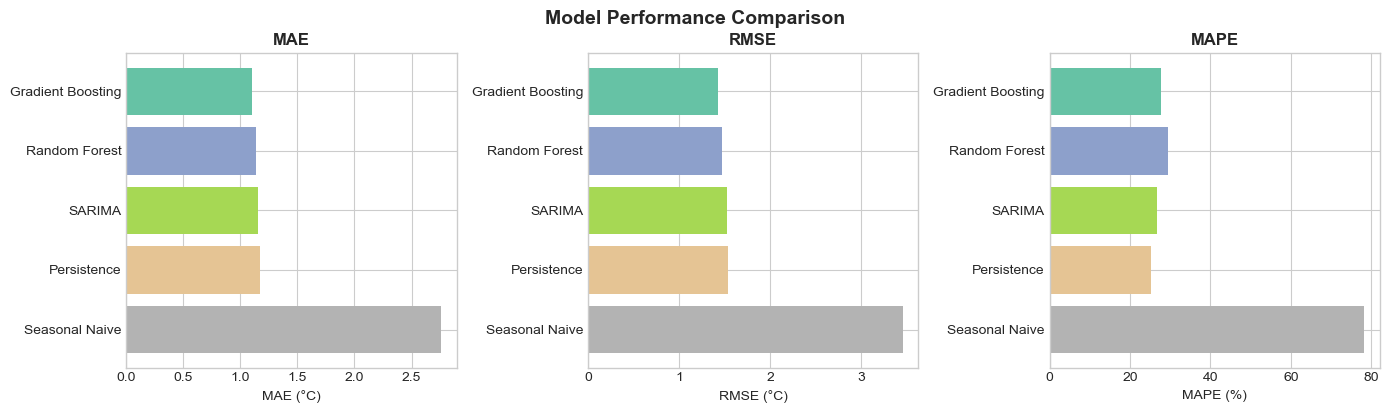

In [204]:
# Visualization of model comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['MAE', 'RMSE', 'MAPE']
colors = plt.cm.Set2(np.linspace(0, 1, len(results)))

for i, metric in enumerate(metrics):
    values = [results[model][metric] for model in results_df.index]
    bars = axes[i].barh(results_df.index, values, color=colors)
    axes[i].set_xlabel(f'{metric} ({"°C" if metric != "MAPE" else "%"})')
    axes[i].set_title(metric, fontweight='bold')
    axes[i].invert_yaxis()
    
plt.tight_layout()
plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.show()

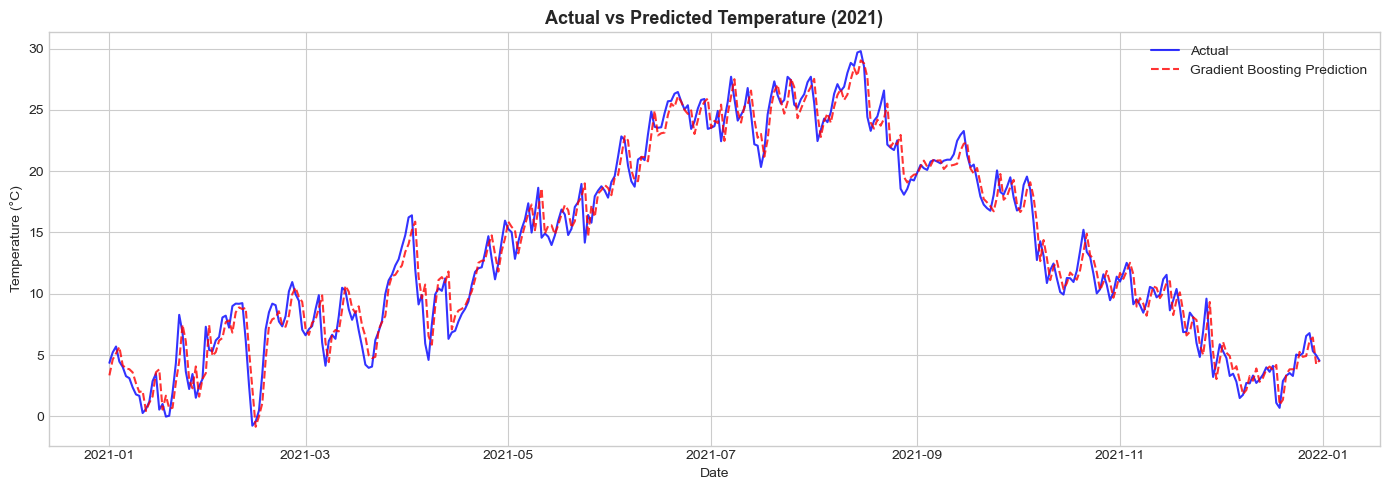

In [205]:
# Prediction vs Actual plot for best model
fig, ax = plt.subplots(figsize=(14, 5))

# Plot subset for clarity
plot_start = '2021-01-01'
plot_end = '2021-12-31'
plot_mask = (test.index >= plot_start) & (test.index <= plot_end)

ax.plot(test.index[plot_mask], y_test.values[plot_mask], 'b-', label='Actual', linewidth=1.5, alpha=0.8)
ax.plot(test.index[plot_mask], y_pred_gb[plot_mask], 'r--', label='Gradient Boosting Prediction', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Actual vs Predicted Temperature (2021)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Residual Analysis

Mean      : -0.0124 °C
Std Dev   : 1.4312 °C
Skewness  : -0.7296
Kurtosis  : 1.3503
Min       : -7.461 °C
Max       : 4.526 °C
Shapiro-Wilk test: W=0.9699, p=2.6436e-14
Residuals are NOT normally distributed (α=0.05)


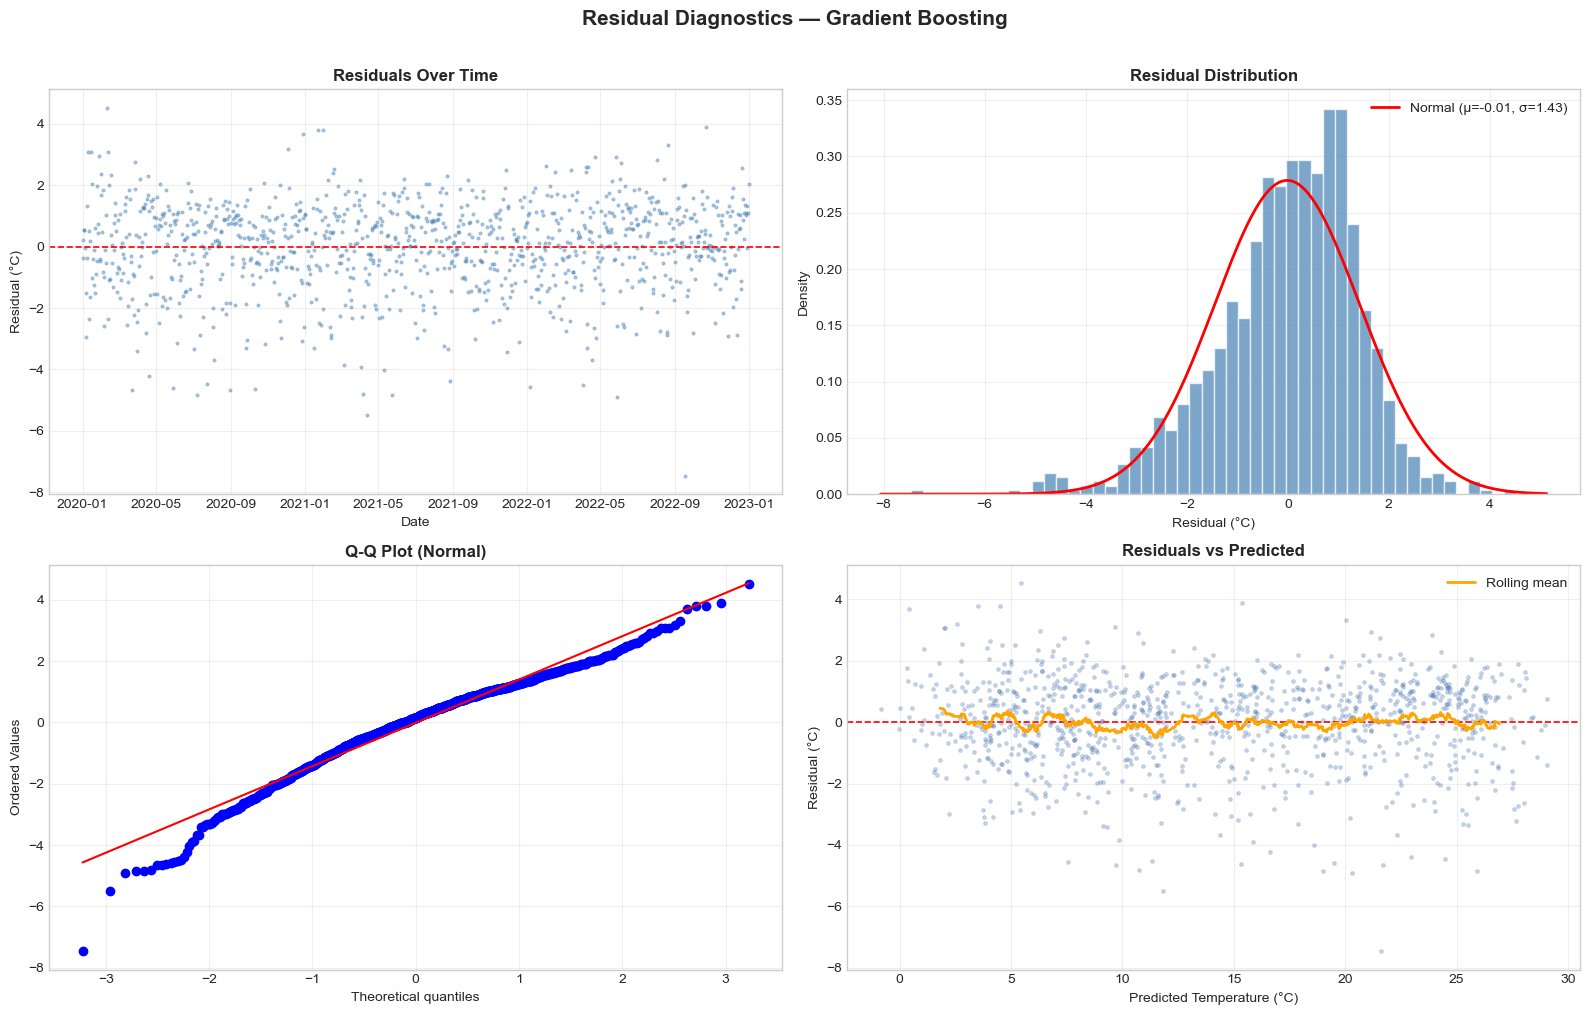

In [206]:
residuals_gb = y_test.values - y_pred_gb

print(f'Mean      : {np.mean(residuals_gb):+.4f} °C')
print(f'Std Dev   : {np.std(residuals_gb):.4f} °C')
print(f'Skewness  : {stats.skew(residuals_gb):.4f}')
print(f'Kurtosis  : {stats.kurtosis(residuals_gb):.4f}')
print(f'Min       : {np.min(residuals_gb):.3f} °C')
print(f'Max       : {np.max(residuals_gb):.3f} °C')

# Shapiro-Wilk normality test (on a sample if dataset is large)
sample_resid = np.random.RandomState(42).choice(residuals_gb, size=min(5000, len(residuals_gb)), replace=False)
sw_stat, sw_p = stats.shapiro(sample_resid)
print(f'Shapiro-Wilk test: W={sw_stat:.4f}, p={sw_p:.4e}')
print(f'Residuals are {"NOT " if sw_p < 0.05 else ""}normally distributed (α=0.05)')

# 4-panel residual diagnostic plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Residuals over time
axes[0, 0].plot(test.index, residuals_gb, 'o', ms=2, alpha=0.4, color='steelblue')
axes[0, 0].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Residual (°C)')
axes[0, 0].set_title('Residuals Over Time', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

#  Histogram + KDE
axes[0, 1].hist(residuals_gb, bins=50, density=True, color='steelblue', alpha=0.7, edgecolor='white')
# Overlay normal fit
xmin, xmax = axes[0, 1].get_xlim()
x_norm = np.linspace(xmin, xmax, 200)
mu, sigma = np.mean(residuals_gb), np.std(residuals_gb)
axes[0, 1].plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), 'r-', linewidth=2, label=f'Normal (μ={mu:.2f}, σ={sigma:.2f})')
axes[0, 1].set_xlabel('Residual (°C)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Residual Distribution', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

#  Q-Q plot
stats.probplot(residuals_gb, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normal)', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Residuals vs Predicted (check heteroscedasticity)
axes[1, 1].scatter(y_pred_gb, residuals_gb, s=8, alpha=0.35, color='steelblue', edgecolors='navy', linewidths=0.2)
axes[1, 1].axhline(0, color='red', linewidth=1.2, linestyle='--')
# Add rolling mean of residuals binned by predicted value
pred_order = np.argsort(y_pred_gb)
window = len(y_pred_gb) // 20
if window > 1:
    rolling_resid = pd.Series(residuals_gb[pred_order]).rolling(window, center=True).mean()
    axes[1, 1].plot(y_pred_gb[pred_order], rolling_resid, 'orange', linewidth=2, label='Rolling mean')
    axes[1, 1].legend()
axes[1, 1].set_xlabel('Predicted Temperature (°C)')
axes[1, 1].set_ylabel('Residual (°C)')
axes[1, 1].set_title('Residuals vs Predicted', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Residual Diagnostics — Gradient Boosting', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

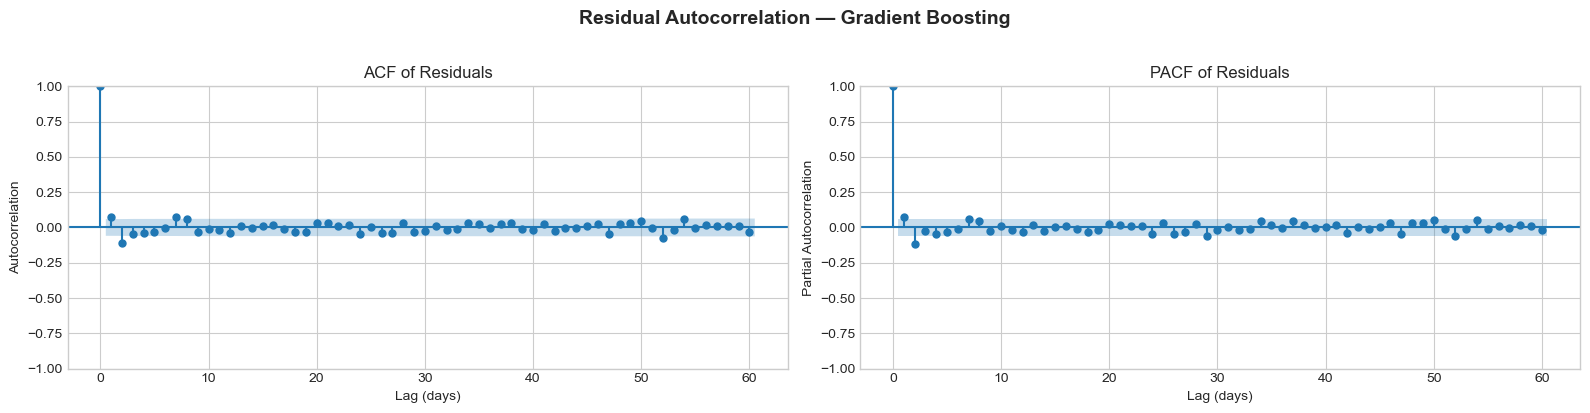

Ljung-Box Test for Residual Autocorrelation:
    lb_stat  lb_pvalue
7   31.1879     0.0001
14  38.5932     0.0004
30  53.1670     0.0057


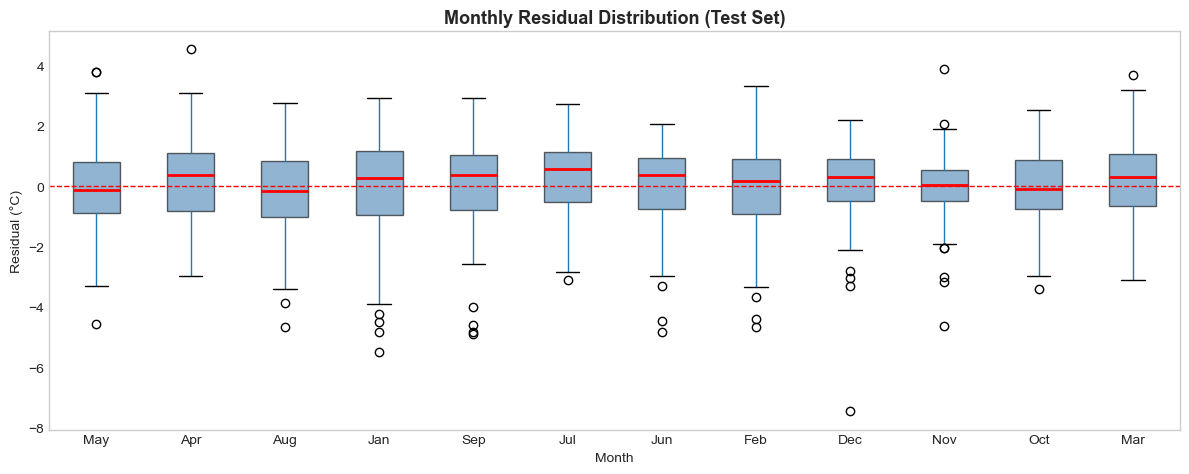

In [207]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plot_acf(residuals_gb, lags=60, ax=axes[0], title='ACF of Residuals')
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('Autocorrelation')

plot_pacf(residuals_gb, lags=60, ax=axes[1], title='PACF of Residuals', method='ywm')
axes[1].set_xlabel('Lag (days)')
axes[1].set_ylabel('Partial Autocorrelation')

plt.suptitle('Residual Autocorrelation — Gradient Boosting', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Ljung-Box test for residual autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_result = acorr_ljungbox(residuals_gb, lags=[7, 14, 30], return_df=True)
print('Ljung-Box Test for Residual Autocorrelation:')
print(lb_result.round(4))

# Monthly residual boxplot
resid_df = pd.DataFrame({
    'residual': residuals_gb,
    'month': test.index.month,
    'month_name': test.index.strftime('%b')
})

# Sort by month order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
months_present = [m for m in month_order if m in resid_df['month_name'].values]

fig, ax = plt.subplots(figsize=(12, 5))
resid_df.boxplot(column='residual', by='month_name', positions=[months_present.index(m) for m in resid_df.groupby('month_name').groups if m in months_present],
                 ax=ax, grid=False, patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.6),
                 medianprops=dict(color='red', linewidth=2))
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xticklabels(months_present)
ax.set_xlabel('Month')
ax.set_ylabel('Residual (°C)')
ax.set_title('Monthly Residual Distribution (Test Set)', fontweight='bold', fontsize=13)
fig.suptitle('')  # remove pandas default suptitle
plt.tight_layout()
plt.show()

## Feature Importance

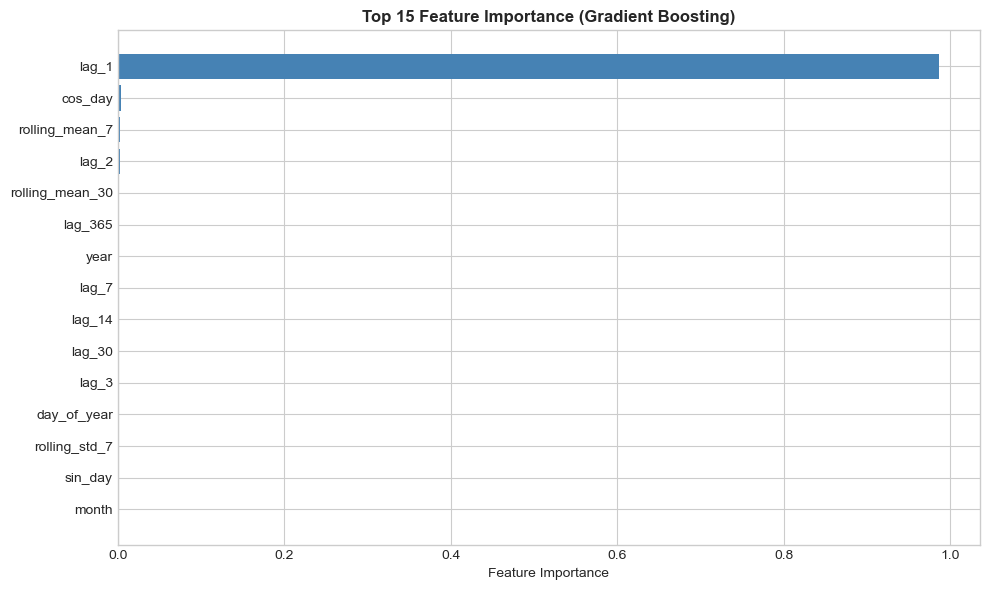

In [208]:
# Feature importance from Gradient Boosting
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance['feature'][:15], feature_importance['importance'][:15], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Feature Importance (Gradient Boosting)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Future Forecasting

In [209]:
# Generate future forecasts using Gradient Boosting model
# to use recursive forecasting for multi-day predictions

def generate_forecast(model, scaler, last_data, n_days):
    forecast = []
    current_data = last_data.copy()
    
    for i in range(n_days):
        # Prepare features for next day
        next_date = current_data.index[-1] + timedelta(days=1)
        
        features = {
            'day_of_year': next_date.timetuple().tm_yday,
            'month': next_date.month,
            'year': next_date.year,
            'sin_day': np.sin(2 * np.pi * next_date.timetuple().tm_yday / 365.25),
            'cos_day': np.cos(2 * np.pi * next_date.timetuple().tm_yday / 365.25),
            'lag_1': current_data['temp_mean'].iloc[-1],
            'lag_2': current_data['temp_mean'].iloc[-2],
            'lag_3': current_data['temp_mean'].iloc[-3],
            'lag_7': current_data['temp_mean'].iloc[-7],
            'lag_14': current_data['temp_mean'].iloc[-14],
            'lag_30': current_data['temp_mean'].iloc[-30],
            'lag_365': current_data['temp_mean'].iloc[-365] if len(current_data) >= 365 else current_data['temp_mean'].mean(),
            'rolling_mean_7': current_data['temp_mean'].iloc[-7:].mean(),
            'rolling_std_7': current_data['temp_mean'].iloc[-7:].std(),
            'rolling_mean_30': current_data['temp_mean'].iloc[-30:].mean(),
        }
        
        # Predict
        X_next = pd.DataFrame([features])[feature_cols]
        X_next_scaled = scaler.transform(X_next)
        pred = model.predict(X_next_scaled)[0]
        
        forecast.append({'date': next_date, 'temp_mean': pred})
        
        # Update current_data with prediction
        new_row = pd.DataFrame({'temp_mean': [pred]}, index=[next_date])
        current_data = pd.concat([current_data, new_row])
    
    return pd.DataFrame(forecast).set_index('date')

# Use last available data
last_known_data = df_clean[['temp_mean']].copy()

# 7-day forecast
forecast_7d = generate_forecast(gb_model, scaler, last_known_data, 7)

# 30-day forecast
forecast_30d = generate_forecast(gb_model, scaler, last_known_data, 30)

print('7-Day Forecast:')
print(forecast_7d.round(2))
print('30-Day Forecast Summary:')
print(forecast_30d.describe().round(2))

7-Day Forecast:
            temp_mean
date                 
2023-01-01       8.16
2023-01-02       7.05
2023-01-03       6.41
2023-01-04       5.89
2023-01-05       5.81
2023-01-06       5.97
2023-01-07       6.17
30-Day Forecast Summary:
       temp_mean
count      30.00
mean        4.94
std         1.12
min         3.33
25%         4.21
50%         4.43
75%         5.87
max         8.16


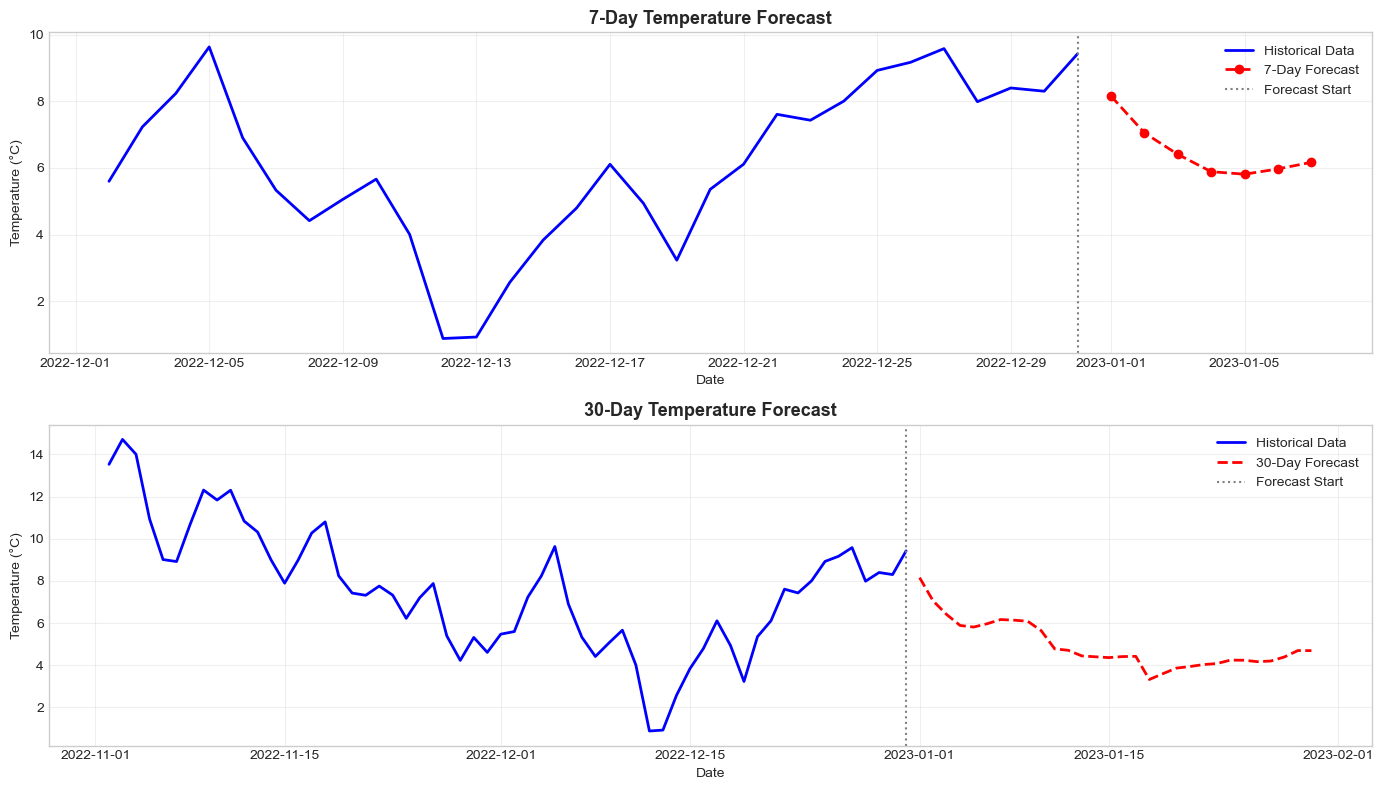

In [210]:
# Visualization of forecasts
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Last 30 days of data + 7-day forecast
recent_data = last_known_data.iloc[-30:]
axes[0].plot(recent_data.index, recent_data['temp_mean'], 'b-', label='Historical Data', linewidth=2)
axes[0].plot(forecast_7d.index, forecast_7d['temp_mean'], 'r--', label='7-Day Forecast', linewidth=2, marker='o')
axes[0].axvline(x=recent_data.index[-1], color='gray', linestyle=':', label='Forecast Start')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('7-Day Temperature Forecast', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Last 60 days of data + 30-day forecast
recent_data_60 = last_known_data.iloc[-60:]
axes[1].plot(recent_data_60.index, recent_data_60['temp_mean'], 'b-', label='Historical Data', linewidth=2)
axes[1].plot(forecast_30d.index, forecast_30d['temp_mean'], 'r--', label='30-Day Forecast', linewidth=2)
axes[1].axvline(x=recent_data_60.index[-1], color='gray', linestyle=':', label='Forecast Start')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title('30-Day Temperature Forecast', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()